In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import re

In [2]:
df = pd.read_csv("eazydiner_cleandata.csv")   
df


,Restaurant_Name,Rating,Area,Dishes,Amount,Location,Restaurant_Discount,discount_value,final_bill
0,Brot Company,5.0,Civil Lines,"Bakery, Pan Asian, Continental",1600,jaipur,20,720.0,880.0
1,Govindam Retreat,4.4,Kanwar Nagar,Multicuisine,700,jaipur,0,0.0,700.0
2,Spice Court,4.4,Civil Lines,"Multicuisine, Beverages",800,jaipur,10,280.0,520.0
3,Cafe Auberge,4.8,Civil Lines,Multicuisine,800,jaipur,20,360.0,440.0
4,Dyore Experiences,3.3,C Scheme,Multicuisine,1800,jaipur,20,810.0,990.0
...,...,...,...,...,...,...,...,...,...
670,Kenzai - Asian Kitchen And Lounge,4.6,Brigade Road,Asian,2000,bengaluru,25,1000.0,1000.0
671,Cahoots Classic Bar House,5.0,Brigade Road,Multicuisine,4000,bengaluru,10,1400.0,2600.0
672,i-Bar,3.8,The Park,Cocktail Menu,2000,bengaluru,30,1100.0,900.0
673,Sea Rock Family Restaurant & Bar,4.7,Seshadripuram,Multicuisine,2000,bengaluru,10,700.0,1300.0


# Separate Numerical and Categorical Columns

In [3]:
numerical_cols = df.select_dtypes(exclude=['object']).columns.to_list()
categorical_cols = df.select_dtypes(include=['object']).columns.to_list()

print("Numerical Columns:", numerical_cols)
print()
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Rating', 'Amount', 'Restaurant_Discount', 'discount_value', 'final_bill']

Categorical Columns: ['Restaurant_Name', 'Area', 'Dishes', 'Location']


# Numerical Columns

In [4]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
numerical_data = df[numerical_cols]
numerical_data

,Rating,Amount,Restaurant_Discount,discount_value,final_bill
0,5.0,1600,20,720.0,880.0
1,4.4,700,0,0.0,700.0
2,4.4,800,10,280.0,520.0
3,4.8,800,20,360.0,440.0
4,3.3,1800,20,810.0,990.0
...,...,...,...,...,...
670,4.6,2000,25,1000.0,1000.0
671,5.0,4000,10,1400.0,2600.0
672,3.8,2000,30,1100.0,900.0
673,4.7,2000,10,700.0,1300.0


# Univariate Numerical Analysis

#### Rating

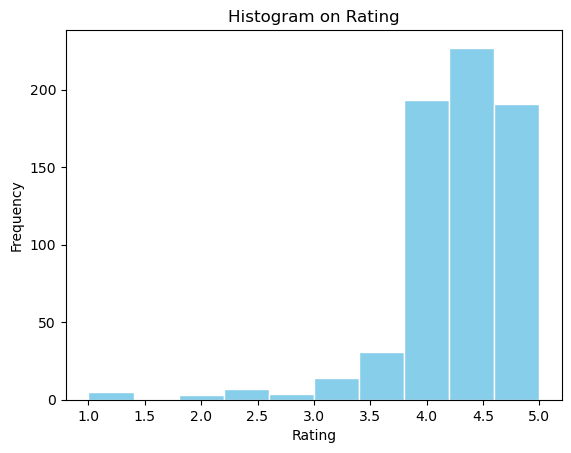

In [47]:
plt.hist(numerical_data['Rating'], bins=10, color='skyblue', edgecolor='White')
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Histogram on Rating")
# plt.grid(True)
plt.show()

## Observation
- Most restaurants have ratings between 4.0 and 5.0, which indicates that the majority of restaurants are performing well and customers are generally satisfied.
- Very few restaurants have ratings below 3.0, showing that low-rated restaurants are rare in the dataset.
- The graph shows that most ratings are high, which means customers are generally happy and most restaurants are doing well.

#### Amount

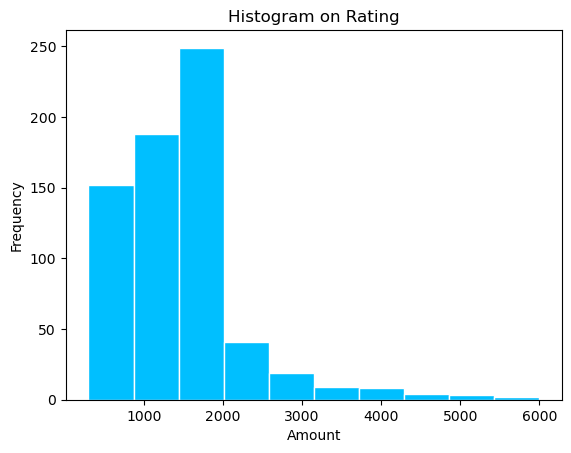

In [51]:
plt.hist(numerical_data['Amount'], bins=10, color='deepskyblue', edgecolor='White')
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Histogram on Rating")
# plt.grid(True)
plt.show()

## Observation
- Most restaurants have a price range between ₹500 and ₹2000 for two people, which means they are affordable for most customers.
- Only a few restaurants have prices above ₹2000, showing they are more expensive.
- Overall, the majority fall in the mid-price range.

#### Discount value

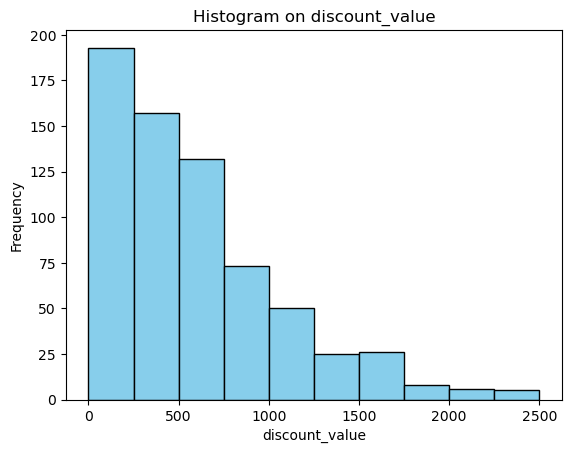

In [7]:
plt.hist(numerical_data['discount_value'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel("discount_value")
plt.ylabel("Frequency")
plt.title("Histogram on discount_value")
# plt.grid(True)
plt.show()

## Observations
- Most restaurants provide discounts below ₹500, indicating that small discount values are very common.
- A noticeable number of restaurants also offer discounts in the range of ₹500–₹1000.
- Discounts between ₹1000–₹1500 are less frequent.
- Very few restaurants give discounts above ₹2000, meaning high-value discounts are quite rare.

#### final Bill

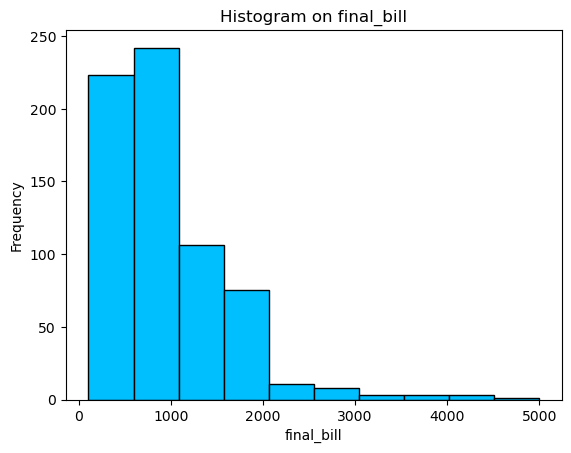

In [52]:
plt.hist(numerical_data['final_bill'], bins=10, color='deepskyblue', edgecolor='black')
plt.xlabel("final_bill")
plt.ylabel("Frequency")
plt.title("Histogram on final_bill")
# plt.grid(True)
plt.show()

## Observations
- Most of the customers have a final bill below ₹1000, indicating that small bills are very common.
- A moderate number of bills fall in the range of ₹1000–₹2000.
- Bills between ₹2000–₹3000 occur less frequently.
- Very few bills exceed ₹3000, showing that high-value bills are quite rare.
- Overall, the data is right-skewed, meaning most transactions are of low value while a few are significantly higher.

# Categorical Columns

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_data = df[categorical_cols]
categorical_data.head()

,Restaurant_Name,Area,Dishes,Location
0,Brot Company,Civil Lines,"Bakery, Pan Asian, Continental",jaipur
1,Govindam Retreat,Kanwar Nagar,Multicuisine,jaipur
2,Spice Court,Civil Lines,"Multicuisine, Beverages",jaipur
3,Cafe Auberge,Civil Lines,Multicuisine,jaipur
4,Dyore Experiences,C Scheme,Multicuisine,jaipur


# Univariate Categorical Analysis

In [10]:
categorical_data["Restaurant_Name"].value_counts().head(10)

Restaurant_Name
Bikaner Elite            3
Spice It                 3
Wow! Momo                3
Barista Coffee           3
Bloom Cafe               3
Biryani By Kilo          2
Peshawri                 2
The Fisherman's Wharf    2
Wow! China               2
SMOOR                    2
Name: count, dtype: int64

In [11]:
categorical_data["Location"].value_counts()

Location
jaipur       135
goa          135
patna        135
mumbai       135
bengaluru    135
Name: count, dtype: int64

In [12]:
categorical_data["Area"].value_counts().head(10)

Area
C Scheme        40
Calangute       25
Kankarbagh      17
Andheri East    13
Powai           13
Anjuna          12
Danapur         12
Candolim        12
Gopalbari       12
Marol           11
Name: count, dtype: int64

In [13]:
categorical_data["Dishes"].value_counts().head(10)

Dishes
Multicuisine                   310
Indian                          34
Cocktail Menu, Multicuisine     20
North Indian                    17
European                        16
Cafe                            11
Chinese, Indian                 11
Continental                     10
Pan Asian                       10
Finger Food, Cocktail Menu       8
Name: count, dtype: int64

#### Location

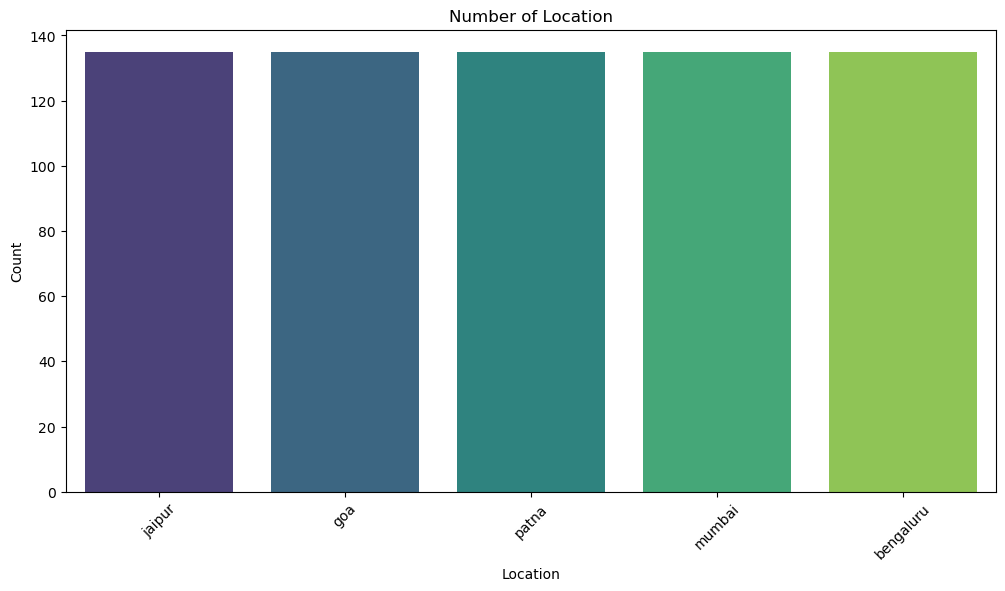

In [53]:
plt.figure(figsize=(12,6))
sns.countplot(data=categorical_data, x='Location', order=categorical_data['Location'].value_counts().head(10).index, palette='viridis')
plt.xticks(rotation=45)
plt.title('Number of Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

## Observations
- The dataset includes restaurants from five main locations — Jaipur, Pune, Delhi, Mumbai, and Bengaluru.

#### Area

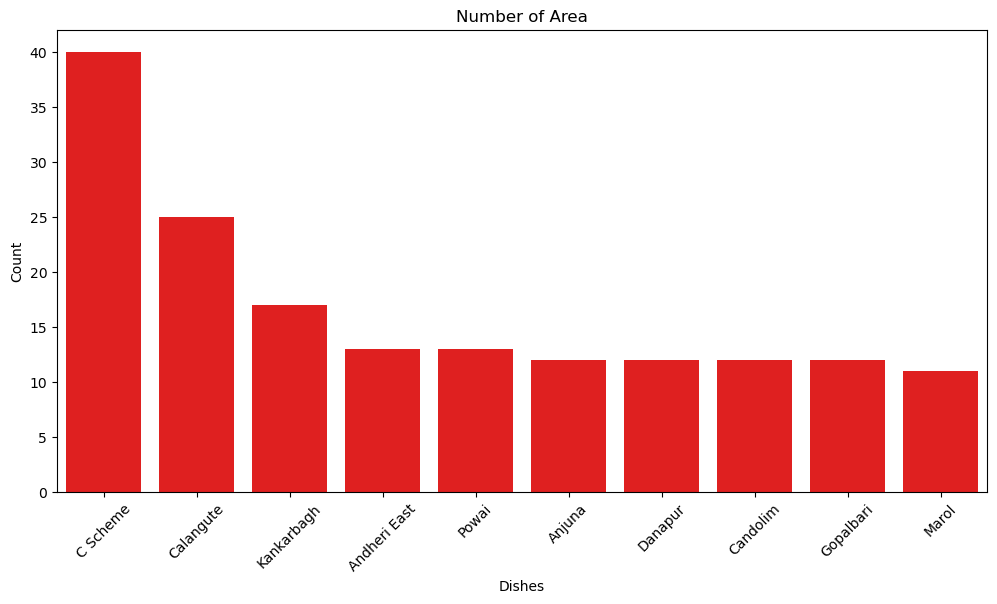

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(data=categorical_data, x='Area', order=categorical_data['Area'].value_counts().head(10).index, color='red')
plt.xticks(rotation=45)
plt.title('Number of Area')
plt.xlabel('Dishes')
plt.ylabel('Count')
plt.show()

## Observations
- C Scheme and Civil Lines have the highest number of restaurants, indicating these are popular dining areas.
- Other areas like Raja Park, Malviya Nagar, and Vaishali Nagar also have a moderate restaurant presence.
- Locations such as Ajmer Road and MI Road have fewer entries, showing less restaurant density.
- The chart suggests that restaurants are concentrated in a few prime areas rather than being evenly spread across all.

#### Dishes

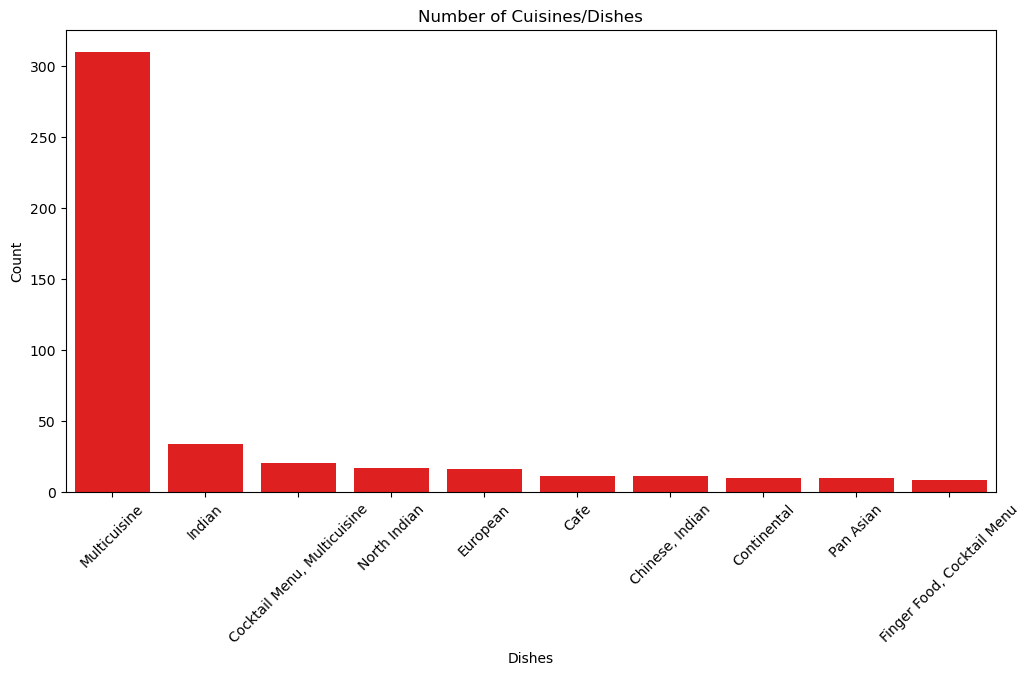

In [54]:
plt.figure(figsize=(12,6))
sns.countplot(data=categorical_data, x='Dishes', order=categorical_data['Dishes'].value_counts().head(10).index, color='red')
plt.xticks(rotation=45)
plt.title('Number of Cuisines/Dishes')
plt.xlabel('Dishes')
plt.ylabel('Count')
plt.show()

## Observations
- Multicuisine is the most common dish type, with a very high count compared to others.
- Dishes like Asian, Bakery, and Beverages are available in fewer restaurants.
- The data indicates that restaurants prefer offering a variety of cuisines rather than specializing in one.
- This shows that customers may favor diversity, making multicuisine options more popular.

# Bivariate Numerical-Numerical Analysis

#### Rating and Amount

In [18]:
restaurant_Rating_Amount = numerical_data[['Rating', 'Amount']]
restaurant_Rating_Amount

,Rating,Amount
0,5.0,1600
1,4.4,700
2,4.4,800
3,4.8,800
4,3.3,1800
...,...,...
670,4.6,2000
671,5.0,4000
672,3.8,2000
673,4.7,2000


In [19]:
restaurant_Rating_Amount.max()

Rating       5.0
Amount    6000.0
dtype: float64

In [20]:
restaurant_Rating_Amount.min()

Rating      1.0
Amount    300.0
dtype: float64

In [21]:
max_amount_restaurant = restaurant_Rating_Amount[restaurant_Rating_Amount["Amount"] == restaurant_Rating_Amount["Amount"].max()]
max_amount_restaurant


,Rating,Amount
25,4.7,6000
63,5.0,6000


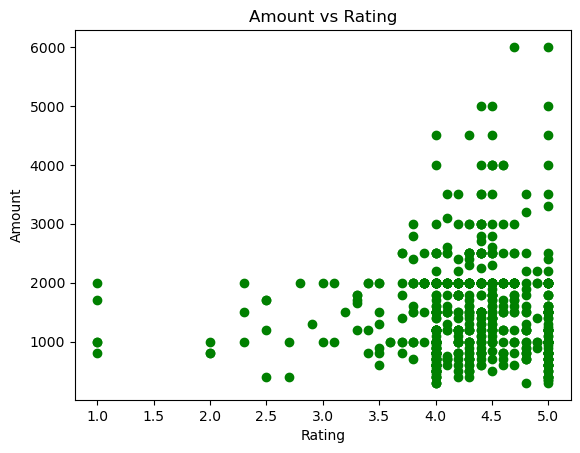

In [22]:
plt.scatter(restaurant_Rating_Amount["Rating"], restaurant_Rating_Amount["Amount"], color='green')
plt.title("Amount vs Rating")
plt.ylabel("Amount")
plt.xlabel("Rating")
plt.show()


## Observations
- Most restaurant ratings are between 3.5 and 5.0.
- The spending amount varies a lot for the same rating.
- There is no clear relation between rating and amount.
- A few restaurants with high spending (around ₹6000) have ratings near 5.0.

#### Discount value and Amount

In [23]:
restaurant_discount_Amount = numerical_data[["discount_value", 'Amount']]
restaurant_discount_Amount

,discount_value,Amount
0,720.0,1600
1,0.0,700
2,280.0,800
3,360.0,800
4,810.0,1800
...,...,...
670,1000.0,2000
671,1400.0,4000
672,1100.0,2000
673,700.0,2000


In [24]:
restaurant_discount_Amount.max()

discount_value    2500.0
Amount            6000.0
dtype: float64

In [25]:
restaurant_discount_Amount.min()

discount_value      0.0
Amount            300.0
dtype: float64

In [26]:
max_restaurant_discount_Amount = restaurant_discount_Amount[restaurant_discount_Amount["Amount"] == restaurant_discount_Amount["Amount"].max()]
max_restaurant_discount_Amount


,discount_value,Amount
25,1500.0,6000
63,1500.0,6000


In [27]:
min_restaurant_discount_Amount = restaurant_discount_Amount[restaurant_discount_Amount["Amount"] == restaurant_discount_Amount["Amount"].min()]
min_restaurant_discount_Amount


,discount_value,Amount
12,195.0,300
226,195.0,300
337,165.0,300
382,120.0,300
402,105.0,300


In [28]:
min_restaurant_discount = restaurant_discount_Amount[restaurant_discount_Amount["discount_value"] == restaurant_discount_Amount["discount_value"].min()]
min_restaurant_discount


,discount_value,Amount
1,0.0,700
5,0.0,600
33,0.0,2000
65,0.0,800
70,0.0,3000
...,...,...
611,0.0,5000
629,0.0,600
635,0.0,2000
636,0.0,2000


In [29]:
max_restaurant_discount_Amount = restaurant_discount_Amount[restaurant_discount_Amount["discount_value"] == restaurant_discount_Amount["discount_value"].max()]
max_restaurant_discount_Amount


,discount_value,Amount
522,2500.0,5000


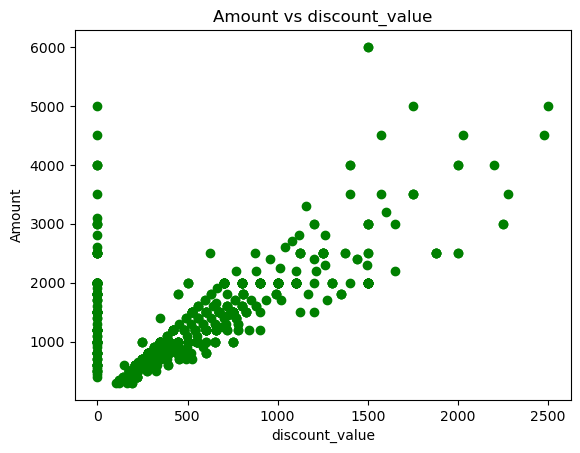

In [30]:
plt.scatter(restaurant_discount_Amount["discount_value"], restaurant_discount_Amount["Amount"], color='green')
plt.title("Amount vs discount_value")
plt.ylabel("Amount")
plt.xlabel("discount_value")
plt.show()


## Observations
- As the discount value increases, the amount spent also increases.
- There is a positive correlation between discount value and amount.
- Higher discounts are mostly associated with higher spending amounts.
- A few outliers show very high spending even with moderate discounts.

# Bivariate Categorical–Categorical Analysis

In [56]:
a = categorical_data[["Dishes","Location"]].value_counts()
a.head(50)

Dishes                       Location 
Multicuisine                 patna        74
                             goa          66
                             jaipur       62
                             bengaluru    60
                             mumbai       48
Indian                       patna        18
Cocktail Menu, Multicuisine  jaipur        9
Chinese, Indian              patna         8
North Indian                 goa           7
European                     mumbai        7
Cocktail Menu, Multicuisine  mumbai        7
Goan                         goa           5
European                     bengaluru     5
Cafe                         goa           5
Continental                  jaipur        5
Finger Food, Cocktail Menu   mumbai        5
Indian                       mumbai        5
North Indian                 mumbai        5
Pan Asian                    mumbai        5
Cocktail Menu, Multicuisine  bengaluru     4
Biryani                      patna         4
Indian          

In [32]:
a = categorical_data[["Dishes","Area"]].value_counts()
a

Dishes                           Area               
Multicuisine                     C Scheme               15
                                 Kankarbagh             11
                                 Calangute               9
                                 Danapur                 9
                                 Andheri East            7
                                                        ..
Beverages, Fast Food             Bais Godam              1
                                 C Scheme                1
Beverages, Finger Food, Biryani  Mantri Square           1
Beverages, Indian                Hard Rock Hotel Goa     1
American, French                 Doddanekkundi           1
Name: count, Length: 495, dtype: int64

<Figure size 1400x800 with 0 Axes>

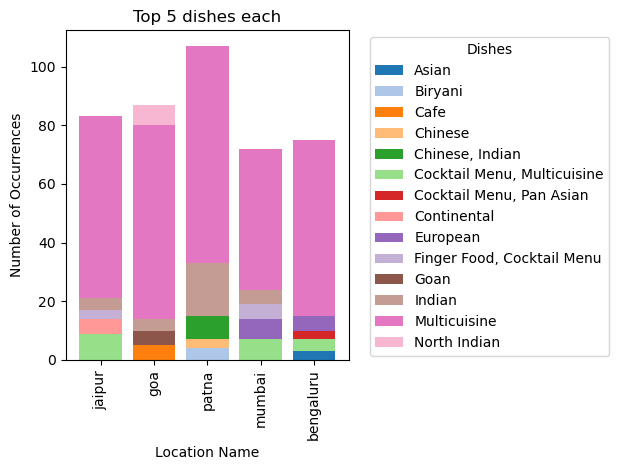

In [58]:
top_restaurants = df['Location'].value_counts().head(10).index.tolist()
top_df = df[df['Location'].isin(top_restaurants)].copy()
top_k_dishes = 5
dish_counts = (
    top_df.groupby(['Location', 'Dishes'])
    .size()
    .reset_index(name='count')
)
dish_counts = dish_counts.sort_values(['Location', 'count'], ascending=[True, False])
dish_counts = dish_counts.groupby('Location').head(top_k_dishes)
pivot = dish_counts.pivot(index='Location', columns='Dishes', values='count').fillna(0)
pivot = pivot.reindex(top_restaurants)

plt.figure(figsize=(14, 8))
colors = sns.color_palette('tab20', n_colors=pivot.shape[1])
pivot.plot(kind='bar', stacked=True, color=colors, width=0.8)
plt.title('Top {} dishes each'.format(top_k_dishes))
plt.xlabel('Location Name')
plt.ylabel('Number of Occurrences')
plt.legend(title='Dishes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Observations
- Patna has the highest number of dish occurrences among all locations.
- Goa and Jaipur also show a good variety of dishes, but less than Patna.
- North Indian and Multicuisine dishes are the most popular across all cities.
- Bengaluru and Mumbai have fewer total dish occurrences compared to Patna and Goa.

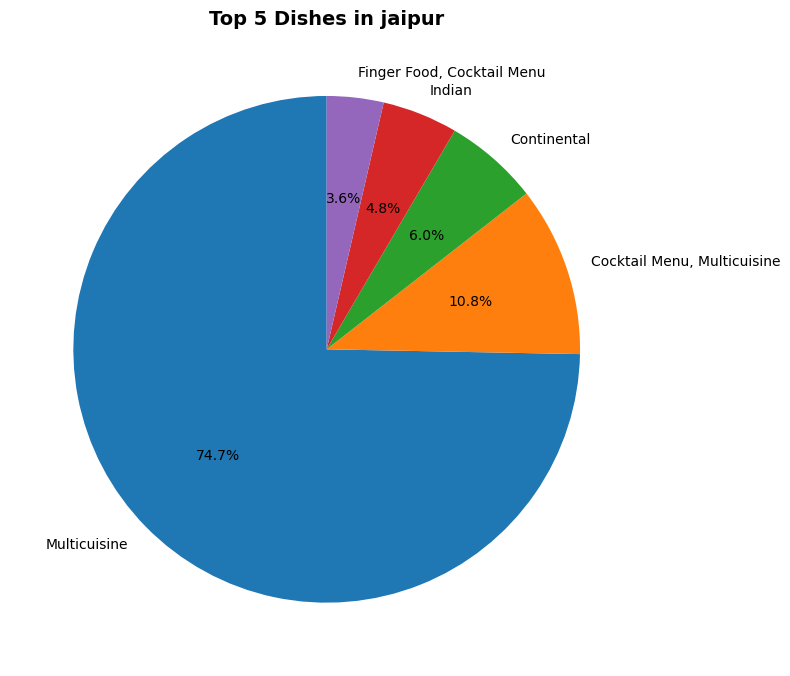

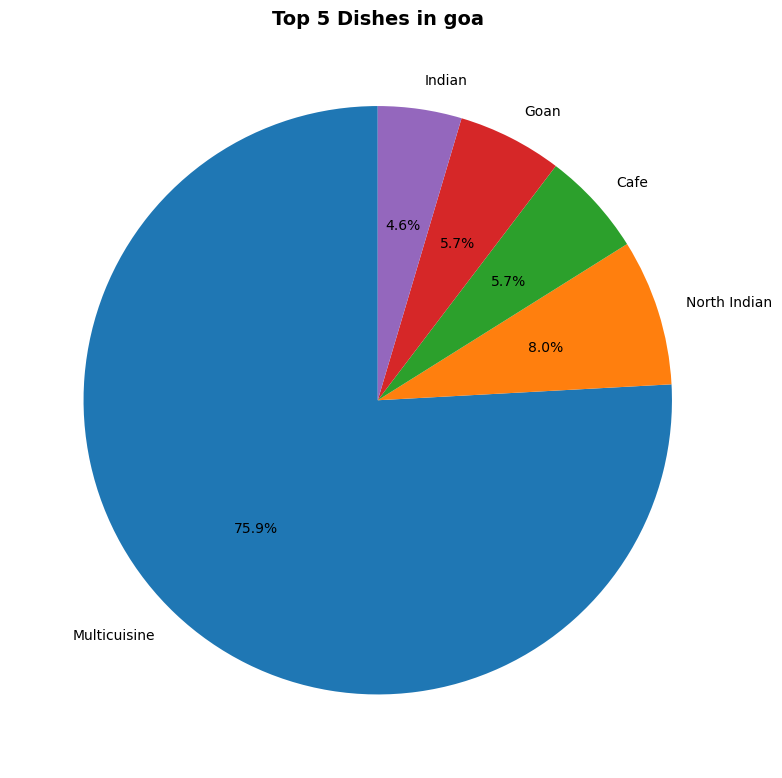

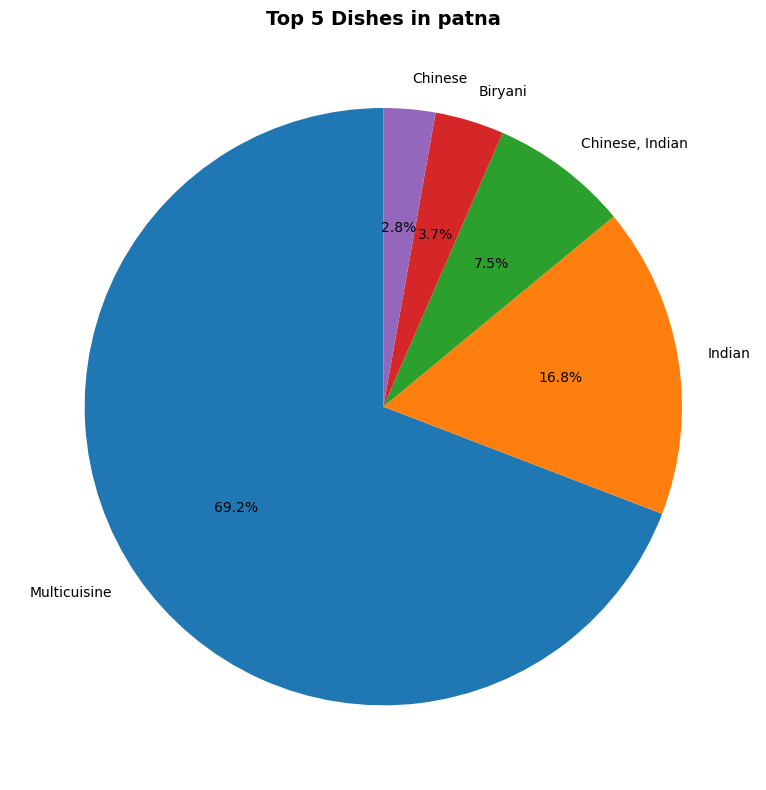

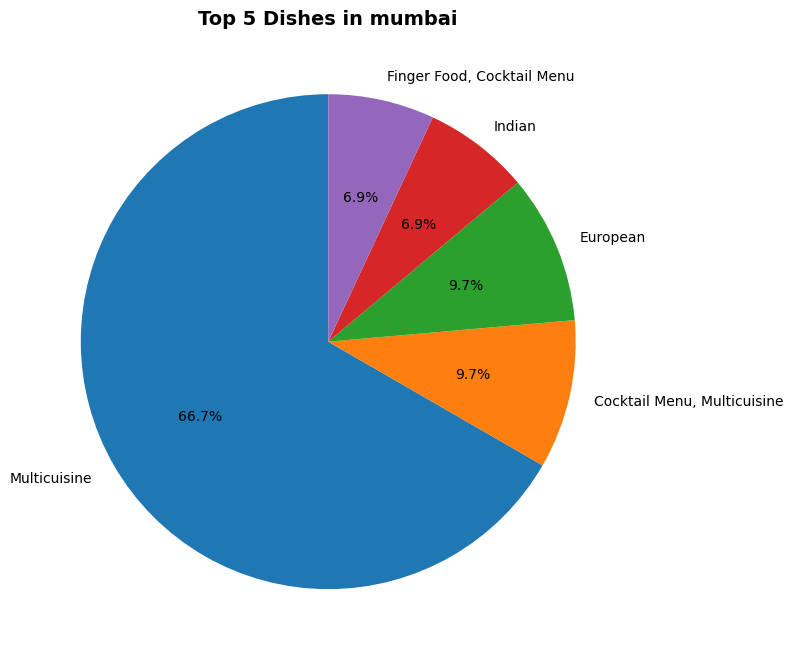

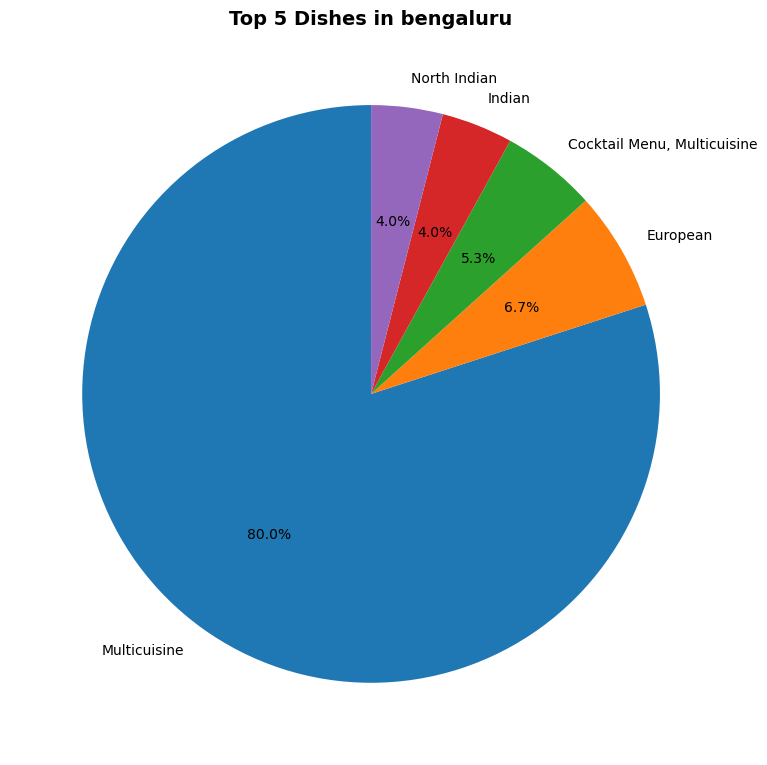

In [39]:
import matplotlib.cm as cm
city = ['jaipur', 'goa', 'patna', 'mumbai', 'bengaluru']

for c in city:
    c_dish = (
        df[df['Location'] == c]
        .groupby('Dishes')['Dishes']
        .value_counts()
        .sort_values(ascending=False)
        .head(5)
    )
    
    plt.figure(figsize=(8, 8))
    
    colors = cm.tab10(np.arange(len(c_dish)))
    
    c_dish.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title(f"Top 5 Dishes in {c}", fontsize=14, weight='bold')
    plt.ylabel('')  
    plt.tight_layout()
    plt.show()

## Observations

- Multicuisine dominates across all five cities — showing it’s the most preferred food category overall.
- Jaipur and Goa have over 70% Multicuisine dishes, indicating strong customer preference for variety.
- Patna has a noticeable share of Indian and Chinese, Indian dishes apart from Multicuisine, showing regional taste influence.
- Mumbai and Bengaluru both show diversity with Pan Asian, European, and Cocktail Menu options — reflecting more international food choices.
- North Indian cuisine appears in several cities but not as dominant — suggesting it’s popular yet secondary to Multicuisine.

# Multivariate Analysis

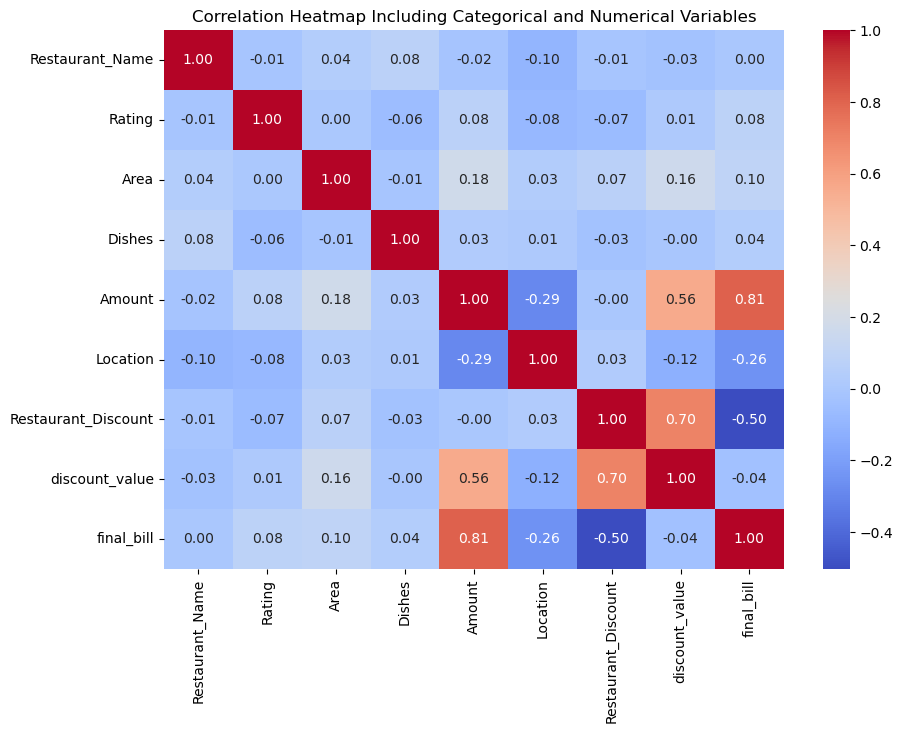

In [40]:
data_encoded = df.copy()
cat_cols = ["Restaurant_Name", "Area", "Dishes", "Location"]
for col in cat_cols:
    data_encoded[col] = data_encoded[col].astype('category').cat.codes

plt.figure(figsize=(10,7))
sns.heatmap(data_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Including Categorical and Numerical Variables")
plt.show()

## Observations

- Amount and final_bill show a strong positive correlation (0.81) — higher order amounts lead to higher final bills.
- Restaurant_Discount and discount_value are also strongly correlated (0.70) — meaning restaurants offering discounts have higher discount values.
- Restaurant_Discount has a negative correlation (-0.50) with final_bill, showing that higher discounts reduce the final bill amount.
- Amount and discount_value have a moderate positive correlation (0.56) — bigger bills often come with higher discounts.
- LOCATION and Amount show a negative correlation (-0.29) — indicating spending patterns vary across locations.
- Other variables like Rating, Dishes, Area have very weak correlations, suggesting they do not strongly influence numerical factors like bill or discount.

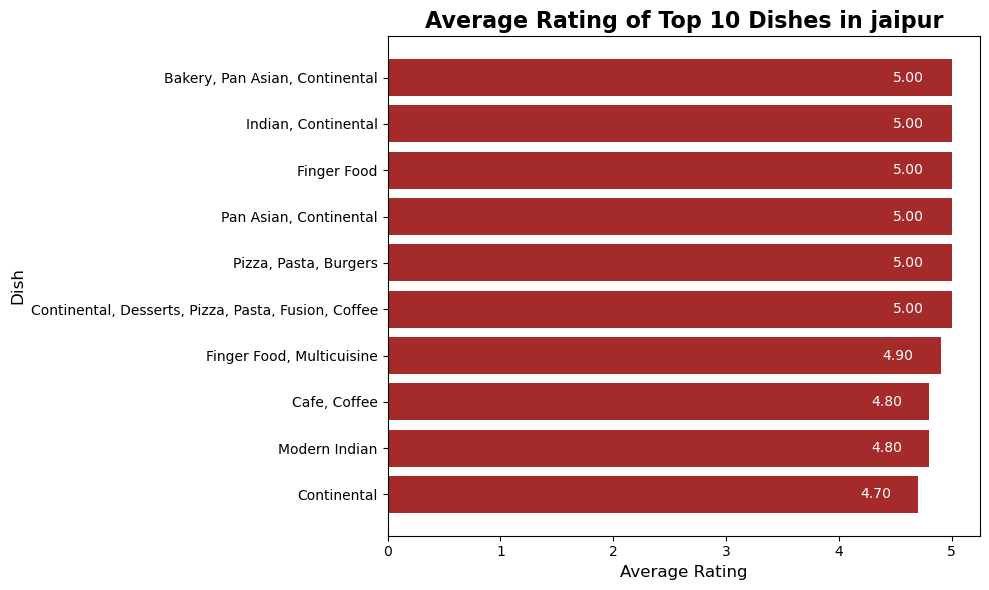

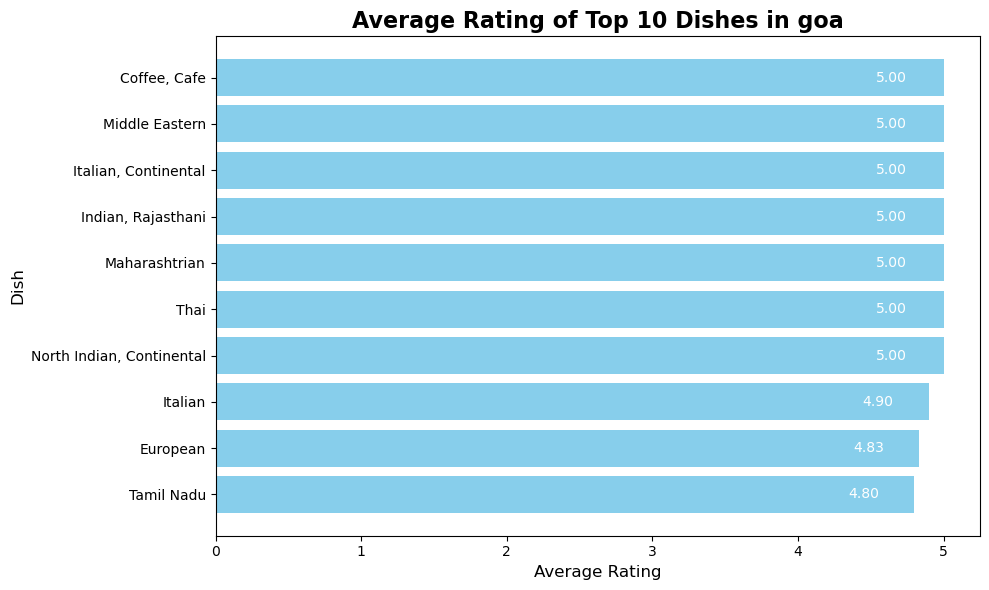

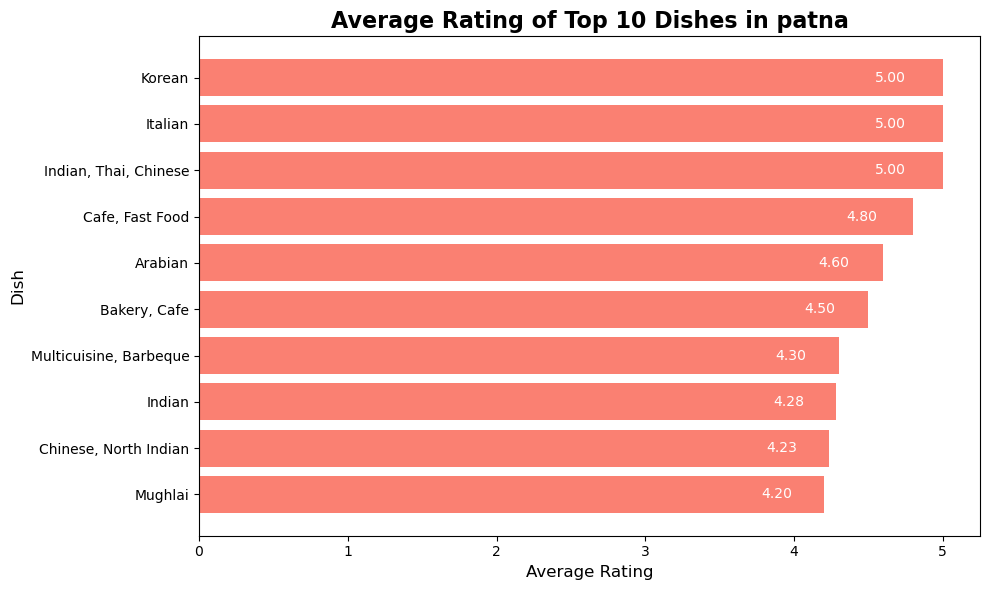

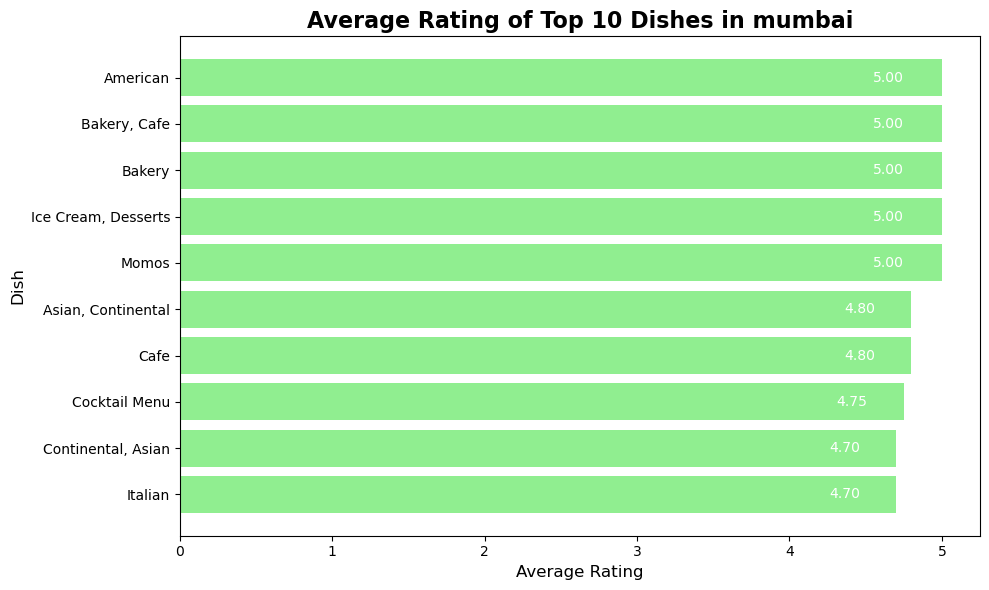

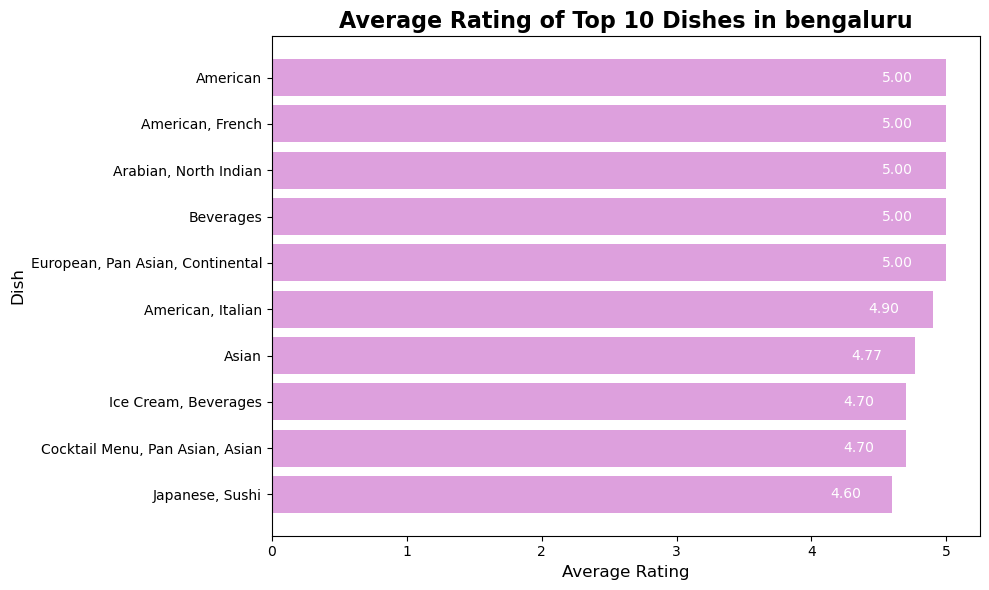

In [41]:
city = ['jaipur', 'goa', 'patna', 'mumbai', 'bengaluru']
colors = ['brown', 'skyblue', 'salmon', 'lightgreen', 'plum']  

for i, c in enumerate(city):
    c_rating = (
        df[df['Location'] == c]
        .groupby('Dishes')['Rating']  
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(c_rating.index, c_rating.values, color=colors[i % len(colors)])
    plt.title(f"Average Rating of Top 10 Dishes in {c}", fontsize=16, weight='bold')
    plt.xlabel("Average Rating", fontsize=12)
    plt.ylabel("Dish", fontsize=12)
    plt.gca().invert_yaxis()  
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width - width*0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', va='center', ha='right', fontsize=10, color='white')
    
    plt.tight_layout()
    plt.show()


## Observation
- Top-rated dishes vary by city, showing that customer taste preferences change from one location to another.
- Mumbai and Bengaluru tend to have higher average ratings overall, suggesting better customer satisfaction or restaurant quality in these cities.
- Some dishes appear consistently in multiple cities’ top lists, showing their wider popularity among customers.
- Cities like Goa and Patna show slightly lower average ratings compared to metro areas, possibly due to fewer high-end restaurants or lower review volumes.

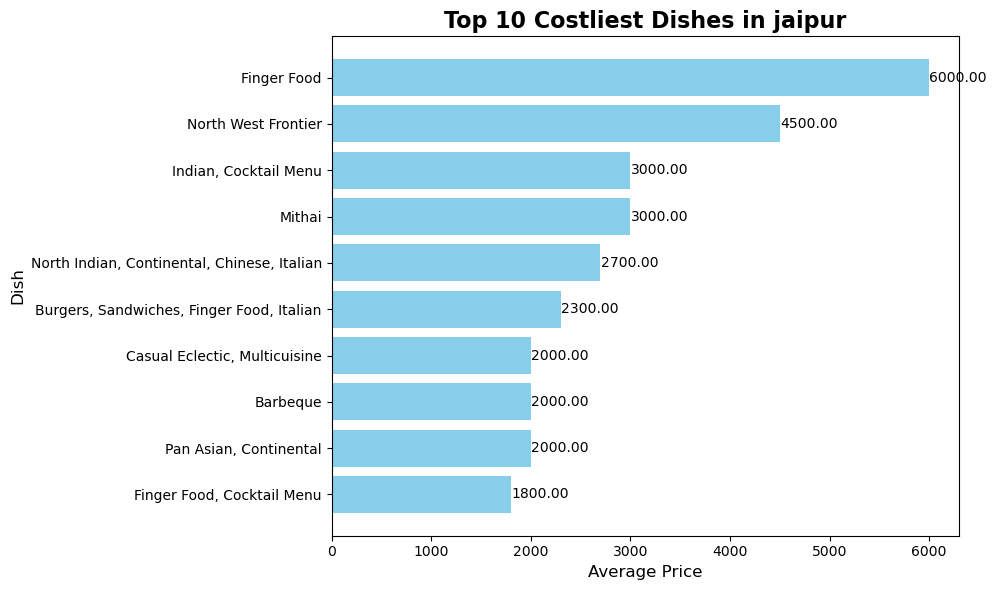

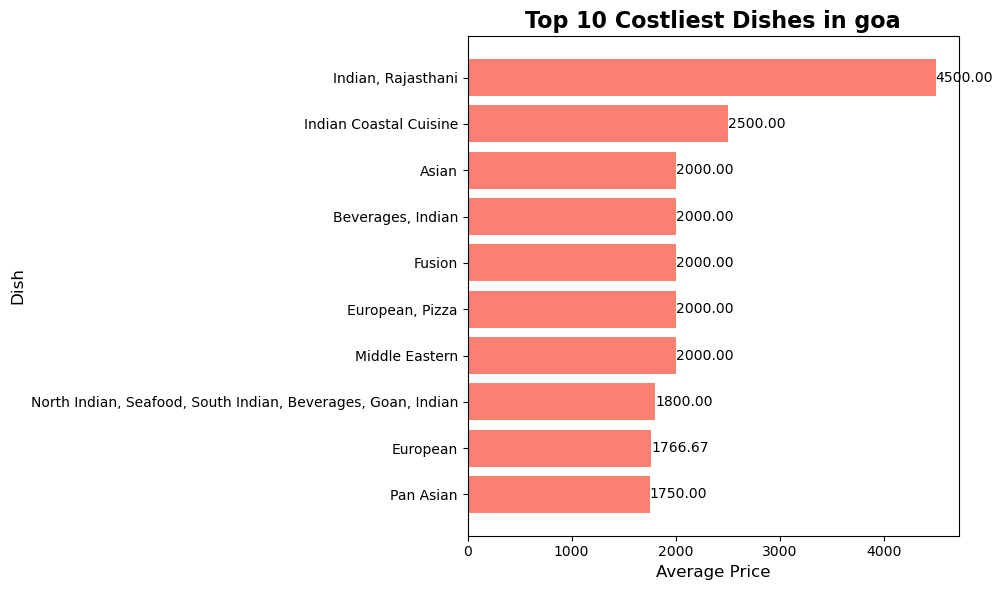

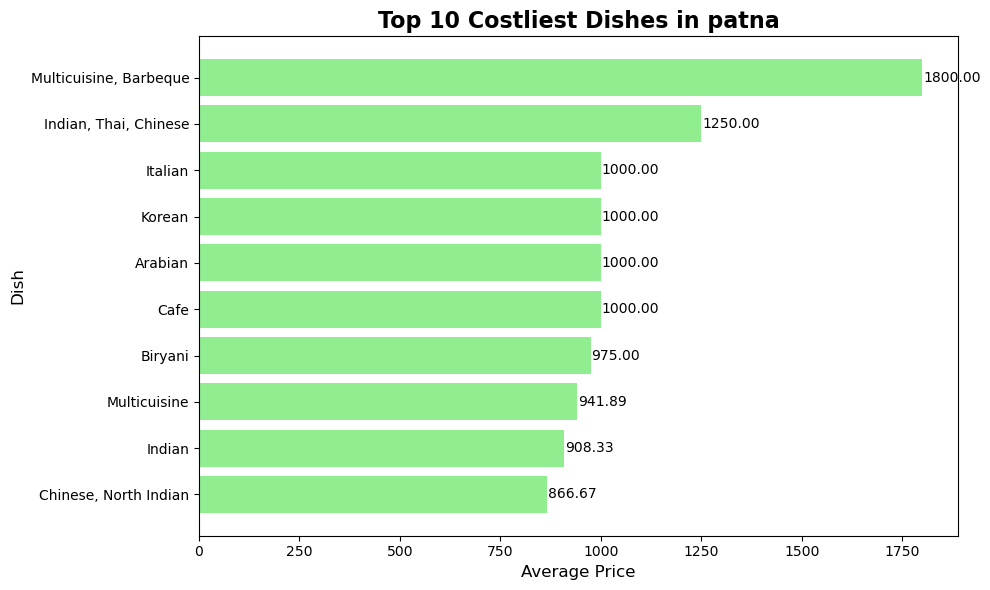

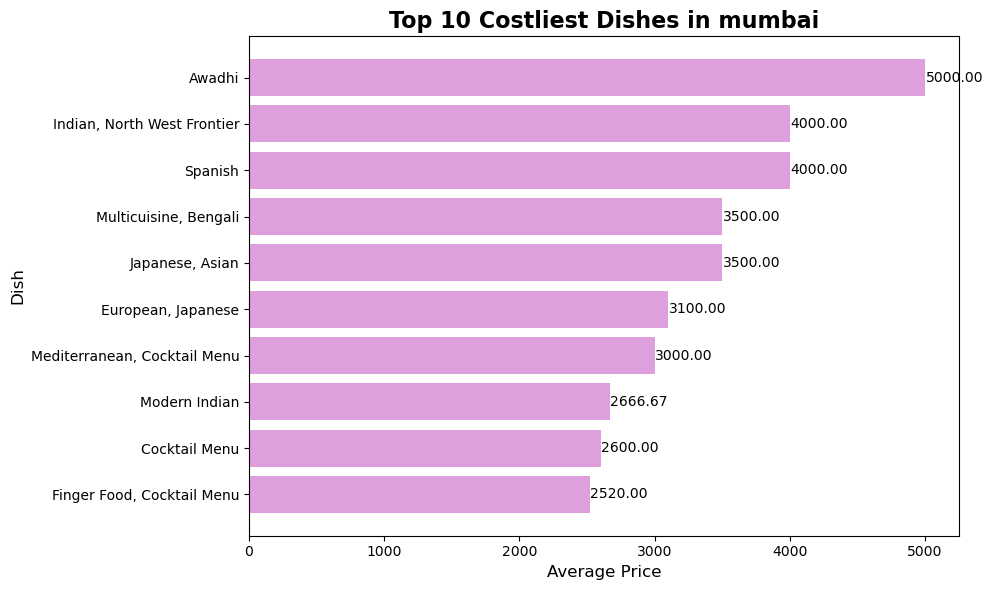

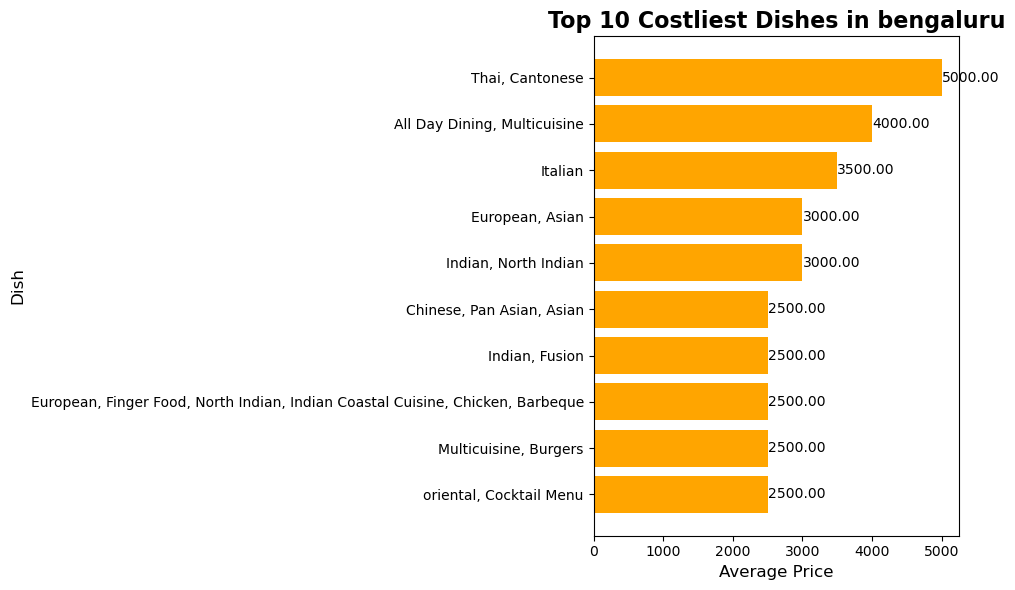

In [60]:
city = ['jaipur', 'goa', 'patna', 'mumbai', 'bengaluru']
colors = ['skyblue', 'salmon', 'lightgreen', 'plum', 'orange']

for i, c in enumerate(city):
    c_approx = (
        df[df['Location'] == c]
        .groupby('Dishes')['Amount']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(c_approx.index, c_approx.values, color=colors[i % len(colors)])
    plt.title(f"Top 10 Costliest Dishes in {c}", fontsize=16, weight='bold')
    plt.xlabel("Average Price", fontsize=12)
    plt.ylabel("Dish", fontsize=12)
    plt.gca().invert_yaxis()  
  
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 2, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()


## Observation

- The average price of dishes varies greatly across cities, indicating different pricing trends based on city standards and restaurant types.
- Mumbai and Bengaluru have the highest-priced dishes, showing these cities have more premium restaurants and high-end dining options.
- Goa and Jaipur show a mix of mid-range and expensive dishes, possibly due to their tourist-friendly nature and local cuisine variety.
- Patna has comparatively lower average dish prices, suggesting a more budget-friendly dining trend in that region.

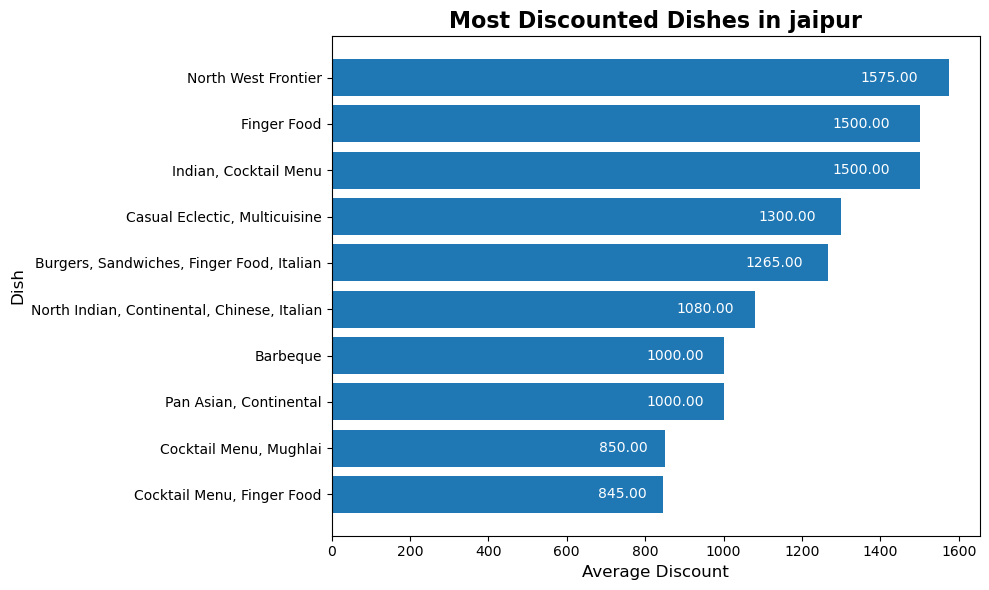

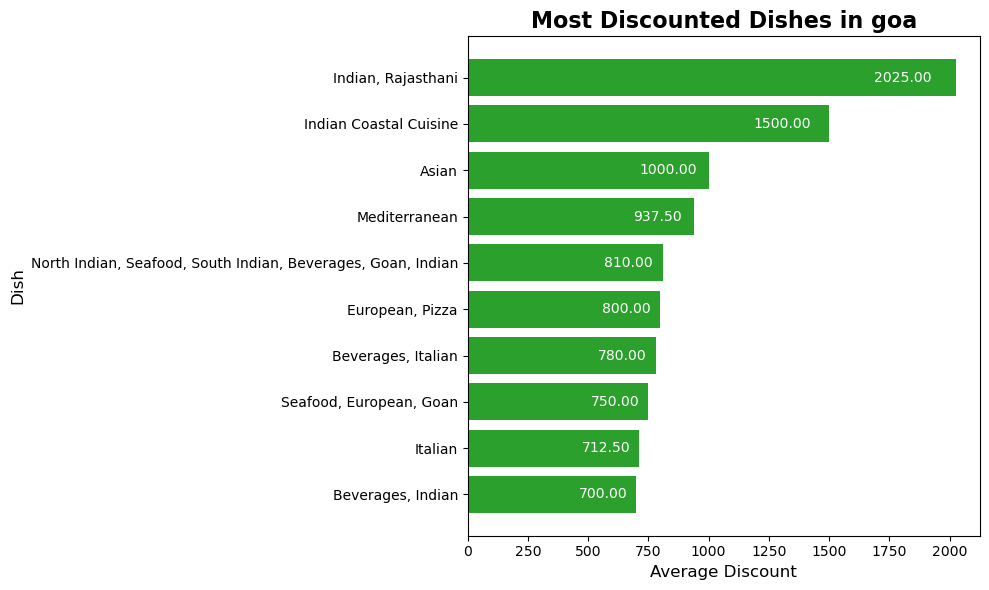

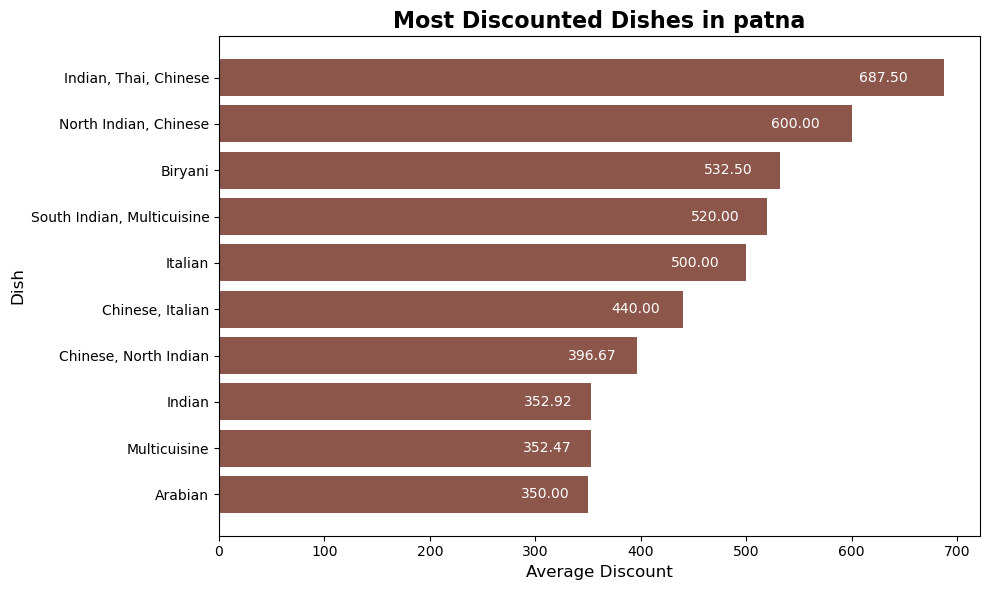

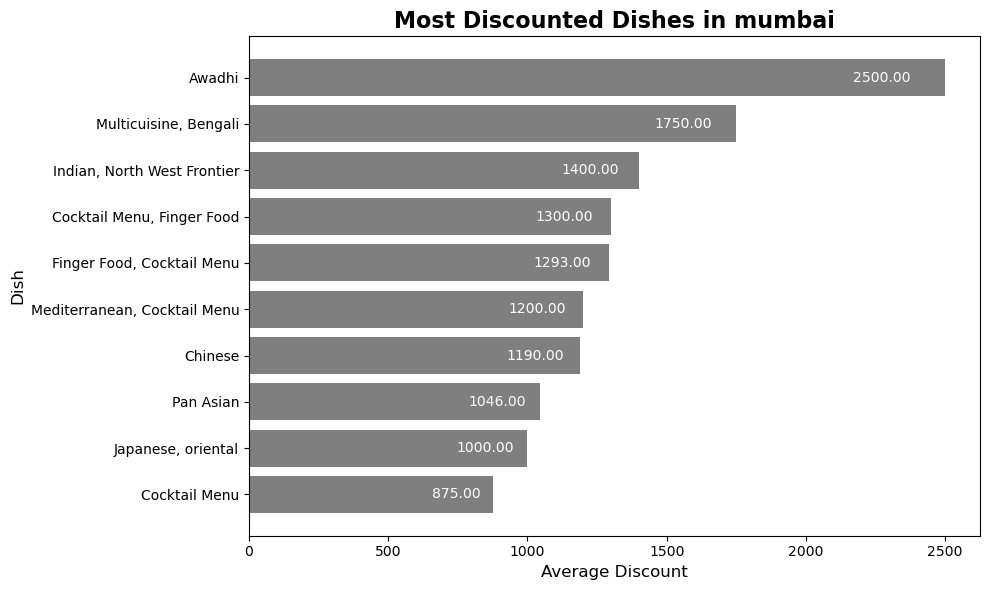

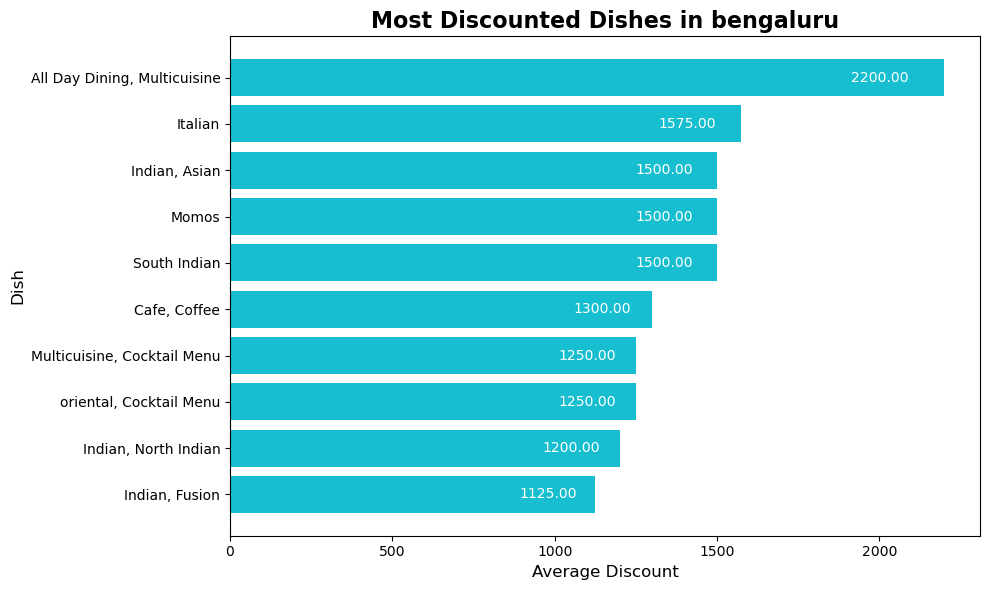

In [43]:
city = ['jaipur', 'goa', 'patna', 'mumbai', 'bengaluru']
n_colors = len(city)
colors = cm.get_cmap('tab10', n_colors).colors  

for i, c in enumerate(city):
    c_discount = (
        df[df['Location'] == c]
        .groupby('Dishes')['discount_value']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(c_discount.index, c_discount.values, color=colors[i])
    plt.title(f"Most Discounted Dishes in {c}", fontsize=16, weight='bold')
    plt.xlabel("Average Discount", fontsize=12)
    plt.ylabel("Dish", fontsize=12)
    plt.gca().invert_yaxis()  
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width - width*0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', va='center', ha='right', fontsize=10, color='white')
    
    plt.tight_layout()
    plt.show()


## Observation

- The average discount percentage differs across cities, showing that restaurants in different locations follow different promotional strategies.
- Mumbai and Bengaluru offer the highest average discounts, likely due to higher competition among restaurants in metro cities.
- Goa and Jaipur show moderate discounts, which could be targeted toward tourists and casual diners.
- Patna has fewer or smaller discounts, suggesting that price-based promotions are less common in that city.

# Overall Observation

After performing Exploratory Data Analysis (EDA) on the dataset, we gained several key insights about the restaurant data and customer behavior. The dataset includes important features such as Restaurant Name, Area, Dishes, Rating, Amount, Discounts, and Location.

- Data Understanding:
The dataset contains both numerical (like Rating, Amount, Discount Value) and categorical columns (like Restaurant Name, Area, Dishes, Location). This helps in analyzing patterns between customer spending, discounts, and restaurant popularity.

- Data Cleaning:
Missing values and duplicate records were checked and handled properly to ensure accuracy in analysis. The dataset was clean and ready for visualization and statistical study.

- Univariate Analysis:
Individual columns were analyzed to understand their distribution. Ratings were mostly high, showing customers generally have positive experiences. Amount and discount columns showed some variation, indicating different price ranges and offers across restaurants.

- Bivariate Analysis:
Relationships between numerical features (like Rating, Amount, Discount, and Final Bill) were explored using correlation heatmaps. A positive correlation was seen between Amount and Final Bill, and discounts were found to reduce the effective bill amount.

- Categorical Analysis:
Count plots helped identify the most popular restaurants, frequently ordered dishes, and top-performing areas. Some restaurants and dishes appeared more frequently, indicating higher customer preference in those categories.

- Location-based Insights:
Analysis of different locations showed which areas had more restaurant listings and higher customer activity. Certain locations showed consistently higher ratings and spending trends.

- Overall Insight:
The analysis shows that customer ratings are generally positive, with moderate spending behavior influenced by discounts and offers. A few restaurants and dishes dominate customer choices, and popular areas have more high-rated restaurants.